# Lab 14

Description of lab:

Understand how to make a simple forecast with an ARIMA model. How to run an ARIMA model with an exogenous variable, and how to create scenarios with exogenous variables. How to model seasonality with ARIMA modeling. 

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns


In [63]:
# VISUALS
# Figure size
plt.rcParams['figure.figsize'] = [16,10]

# Text sizes
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize']= 12
plt.rcParams['font.size'] = 14

# Colors
plt.rcParams['legend.labelcolor'] = '#ffffff'
plt.rcParams['xtick.labelcolor'] = '#ffffff'
plt.rcParams['ytick.labelcolor'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['axes.titlecolor'] = '#ffffff'
plt.rcParams['axes.edgecolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'
plt.rcParams['figure.facecolor'] = '#1f1f1f'
plt.rcParams['axes.facecolor'] = '#1f1f1f'

# Graph colors
from cycler import cycler

diverse = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a', '#b15928', '#a6cee3', '#b2df8a', '#fb9a99']
greens = ['#2ca02c', '#4daf4a', '#45a05a', '#60bd68', '#5cb85c', '#6ba981', '#75bb6f', '#6dae64', '#4c9a5f']
blues = ['#1f78b4', '#377eb8', '#3182bd', '#4292c6', '#5aaed6', '#6baed6', '#7ba3df', '#92b3e4', '#a6bddb']
reds = ['#e41a1c', '#d73027', '#a50026', '#f46d43', '#d73027', '#fdae61', '#fee08b', '#fee08b', '#d73027']

plt.rcParams['axes.prop_cycle'] = cycler(color = diverse)

# Display max columns, pandas dataframes
pd.set_option('display.max_columns', None) 

### Power prices and ETS prices

In [64]:
ets = pd.read_csv("http://jmaurit.github.io/analytics/labs/data/eua-price.csv")
ets.columns = ['date', 'ets_price']

In [65]:
elspot = pd.read_csv("http://jmaurit.github.io/norwayeconomy/data_series/elspot.csv")

In [66]:
elspot['date'] = pd.to_datetime(elspot['date'])
ets['date'] = pd.to_datetime(ets['date'])

In [67]:
ets['month'] = ets['date'].dt.month
ets['year'] = ets['date'].dt.year
ets_monthly = ets.groupby(['year', 'month'])['ets_price'].aggregate('mean')
ets_monthly = ets_monthly.reset_index()
ets_monthly['day'] = 1
ets_monthly['date'] = pd.to_datetime(ets_monthly[['year', 'month', 'day']])

In [68]:
ets_monthly

,year,month,ets_price,day,date
0,2008,4,25.855625,1,2008-04-01
1,2008,5,26.805500,1,2008-05-01
2,2008,6,29.095600,1,2008-06-01
3,2008,7,27.194500,1,2008-07-01
4,2008,8,25.712000,1,2008-08-01
...,...,...,...,...,...
137,2019,10,24.930500,1,2019-10-01
138,2019,11,24.525000,1,2019-11-01
139,2019,12,25.259900,1,2019-12-01
140,2020,1,24.401000,1,2020-01-01


In [69]:
ets_monthly = ets_monthly.loc[:, ['date', 'ets_price']].copy()

In [70]:
dkprices = elspot.loc[:, ['date', 'DK1', 'DK2']]
power_DF = dkprices.merge(ets_monthly, how = 'left', on = 'date')

In [71]:
power_DF

,date,DK1,DK2,ets_price
0,2000-01-01,1779,NaN,NaN
1,2000-02-01,1431,NaN,NaN
2,2000-03-01,1453,NaN,NaN
3,2000-04-01,1593,NaN,NaN
4,2000-05-01,1680,NaN,NaN
...,...,...,...,...
223,2018-08-01,5569,5684.0,19.0950
224,2018-09-01,4989,5179.0,21.4410
225,2018-10-01,4748,5090.0,19.3204
226,2018-11-01,5404,5468.0,19.5105


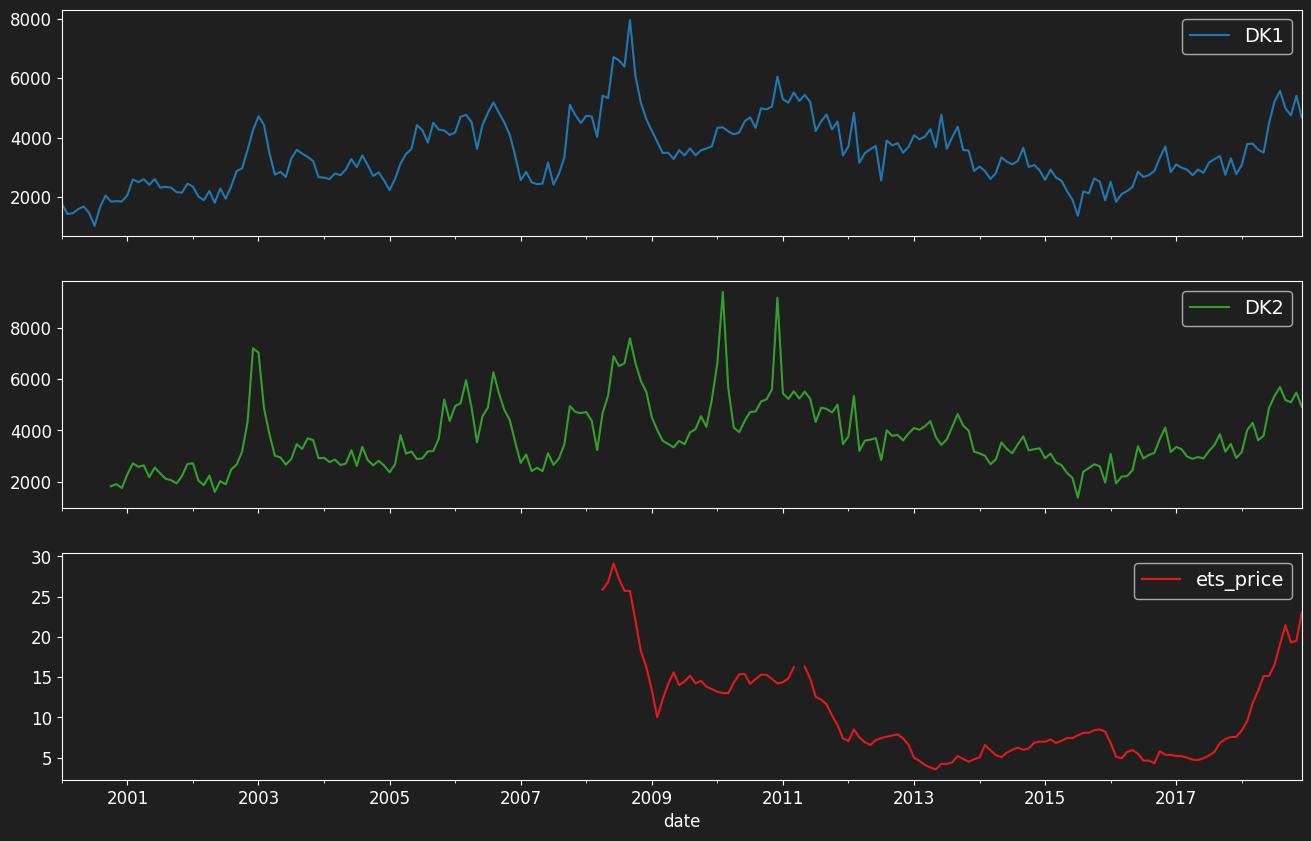

In [72]:
power_DF.set_index('date').plot(subplots = True)
plt.show()

In [73]:
# Downscaling power prices for it to be similar to the ets prices. Dividing by 1 000:
power_DF['DK1'] = power_DF['DK1'] / 1000
power_DF['DK2'] = power_DF['DK2'] / 1000

### Forecasts based on ARIMA models

ARIMA models is a larger class of time series models, AR: Autoregressive, I: Order of integration, MA: Moving Average. In the last lab I created an AR model, where a variable is modeled as a function of its own lagged values. A **Moving Average Model** is also dynamic, but here the dynamics are modeled in the models error term (shocks in the model), not the actual y-values. 

MA model of order 1: MA(1) as: $y_t = c + \epsilon_t + \epsilon_{t - 1}$

MA model of order 2: MA(2) as: $y_t = c + \epsilon_t + \epsilon_{t - 1} + \epsilon_{t - 2}$

Econimic intuition for this model is that an exogenous shock in one period can carry over to later periods. For example: The outbreak of COVID countinues to have reverberations for oil price as an example, even though the epidemic os long over. 

All AR models can be written as MA models, and vice versa. A time series with complex dynamics can often best be modeled as a combination of AR and MA terms. 

In [74]:
# Checking whether the data is stationary:
from statsmodels.tsa.stattools import adfuller

adf_test1 = adfuller(power_DF['DK1'][power_DF['DK1'].notna()], autolag = 'AIC')
adf_test2 = adfuller(power_DF['DK2'][power_DF['DK2'].notna()], autolag = 'AIC')
adf_test3 = adfuller(power_DF['ets_price'][power_DF['ets_price'].notna()], autolag = 'AIC')

In [75]:
print('DK1', adf_test1)
print('DK2', adf_test2)
print('ETS', adf_test3)

DK1 (-3.030001056282569, 0.03218608629600175, 1, 226, {'1%': -3.4596204846395824, '5%': -2.8744153028455948, '10%': -2.5736320761218576}, 311.72544159766596)
DK2 (-4.729780894268517, 7.39554285955711e-05, 0, 218, {'1%': -3.460707667106296, '5%': -2.874891213486339, '10%': -2.573885987711472}, 475.6251266183657)
ETS (-2.3198501163208154, 0.16564581028701875, 4, 123, {'1%': -3.4846672514209773, '5%': -2.8853397507076006, '10%': -2.5794629869786503}, 282.840017367789)


Evaluating test statistics and p-values, we can reject the null-hypothesis for DK1 and DK1 (even though DK1 p-value was close to the critical value .05), they are stationary. We should also consider ETS prices to be non-stationary. 

In [76]:
# Looking at the DK2 series, investingating its form of autocorrelation:
DK2_price = power_DF.loc[power_DF['DK2'].notna(), ['date', 'DK2']].set_index('date')

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

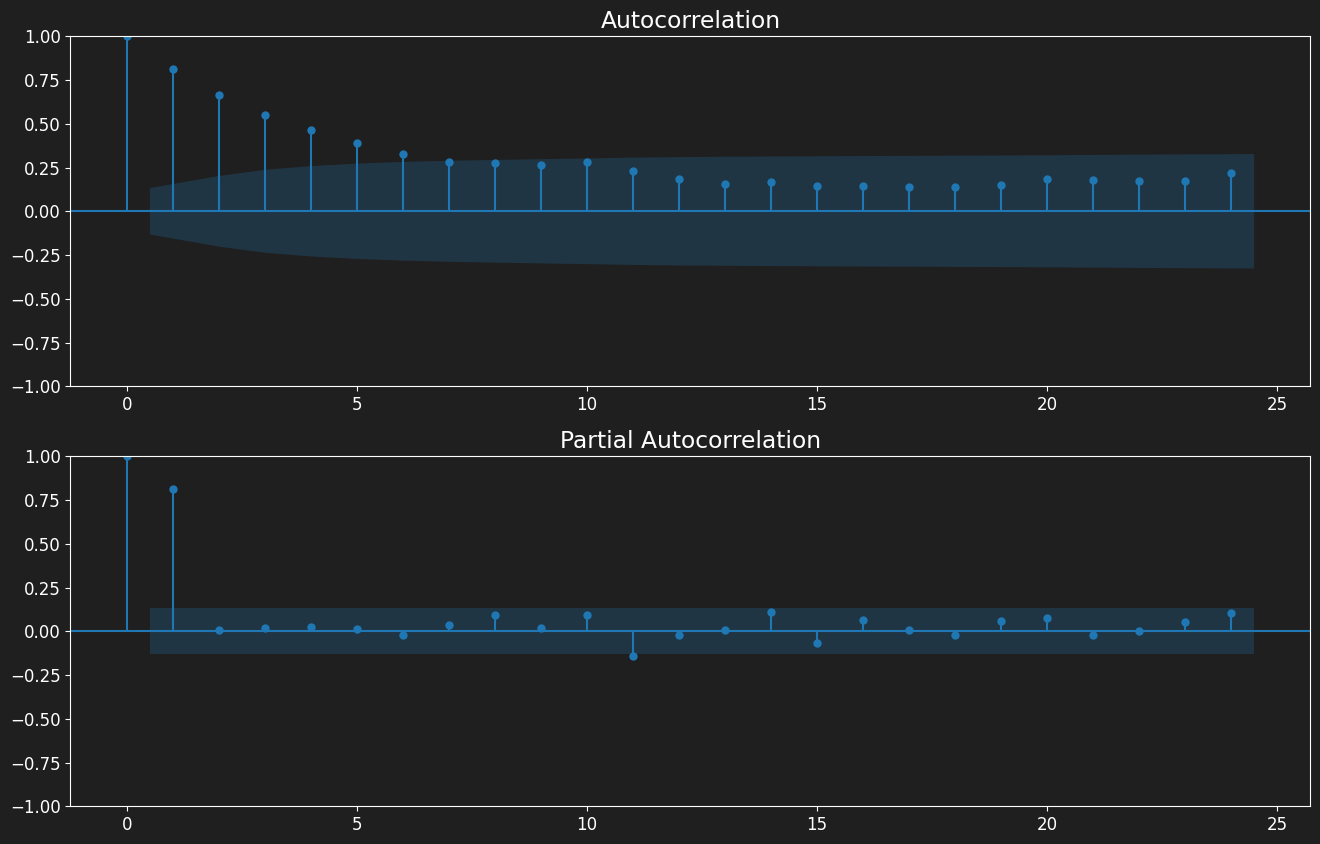

In [77]:
fig, ax = plt.subplots(2, 1)
plot_acf(DK2_price, ax = ax[0])
plot_pacf(DK2_price, ax = ax[1])
plt.show()

In [78]:
# Based in the partial autocorrelation chart, I will create an ARIMA model with 1 AR term:
from statsmodels.tsa.arima.model import ARIMA

arimaMod0 = ARIMA(DK2_price, order = (1, 0, 0)).fit() # order = (AR, I, MA), number of terms.
arimaMod0.summary()

C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    DK2   No. Observations:                  219
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -249.496
Date:                Sat, 09 Dec 2023   AIC                            504.991
Time:                        11:01:04   BIC                            515.159
Sample:                    10-01-2000   HQIC                           509.098
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7208      0.355     10.481      0.000       3.025       4.417
ar.L1          0.8195      0.026     31.771      0.000       0.769       0.870
sigma2         0.5687      0.029     19.428      0.000       0.511       0.626
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               366.25
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               0.45   Skew:                             0.96
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [79]:
# Adding an MA term:
arimaMod1 = ARIMA(DK2_price, order = (1, 0, 1)).fit()
arimaMod1.summary()

C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    DK2   No. Observations:                  219
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -249.453
Date:                Sat, 09 Dec 2023   AIC                            506.906
Time:                        11:01:05   BIC                            520.463
Sample:                    10-01-2000   HQIC                           512.381
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7204      0.363     10.246      0.000       3.009       4.432
ar.L1          0.8279      0.044     18.649      0.000       0.741       0.915
ma.L1         -0.0251      0.069     -0.363      0.716      -0.160       0.110
sigma2         0.5684      0.029     19.320      0.000       0.511       0.626
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               367.13
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.44   Skew:                             0.99
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

A common way of comparing these models is to look at the information criterion (AIC and BIC). These criteria say something about the information loss of the model, we want the model that minimizes this loss. Another way of looking at it: the information criterion balance the competing aims of bias and variance. By adding extra variables we can avoid the bias (underfitting) of not capturing relevant parts of the data. Adding extra variables can however also result in high variance (overfitting), a model that is sensitive to small inconsequential changes in the data. 

Adding the MA term to the model seems to increase the information loss (both AIC and BIC), I will continue with the AR(1) model:

In [80]:
fitted = arimaMod0.fittedvalues

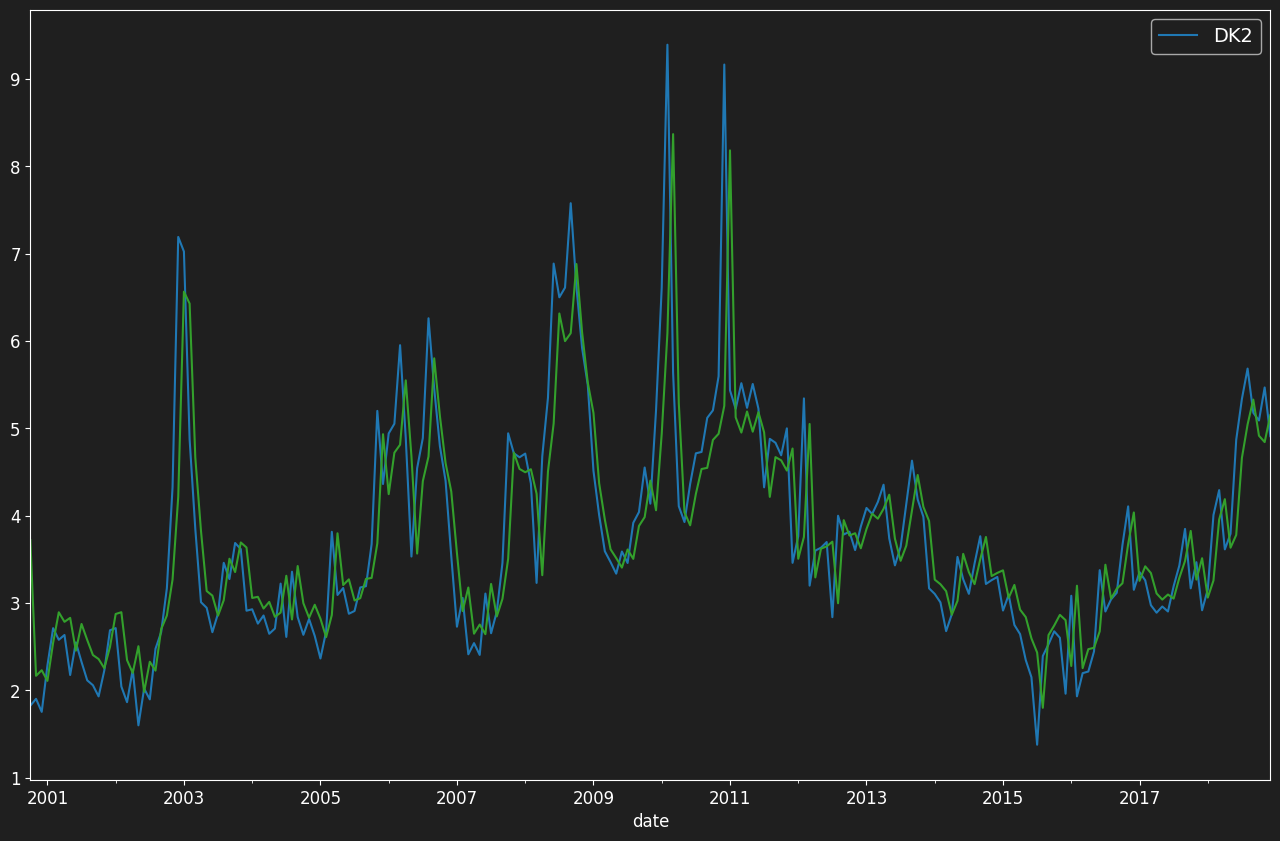

In [81]:
fig, ax = plt.subplots()
DK2_price.plot(ax = ax)
fitted.plot(ax = ax)
plt.show()

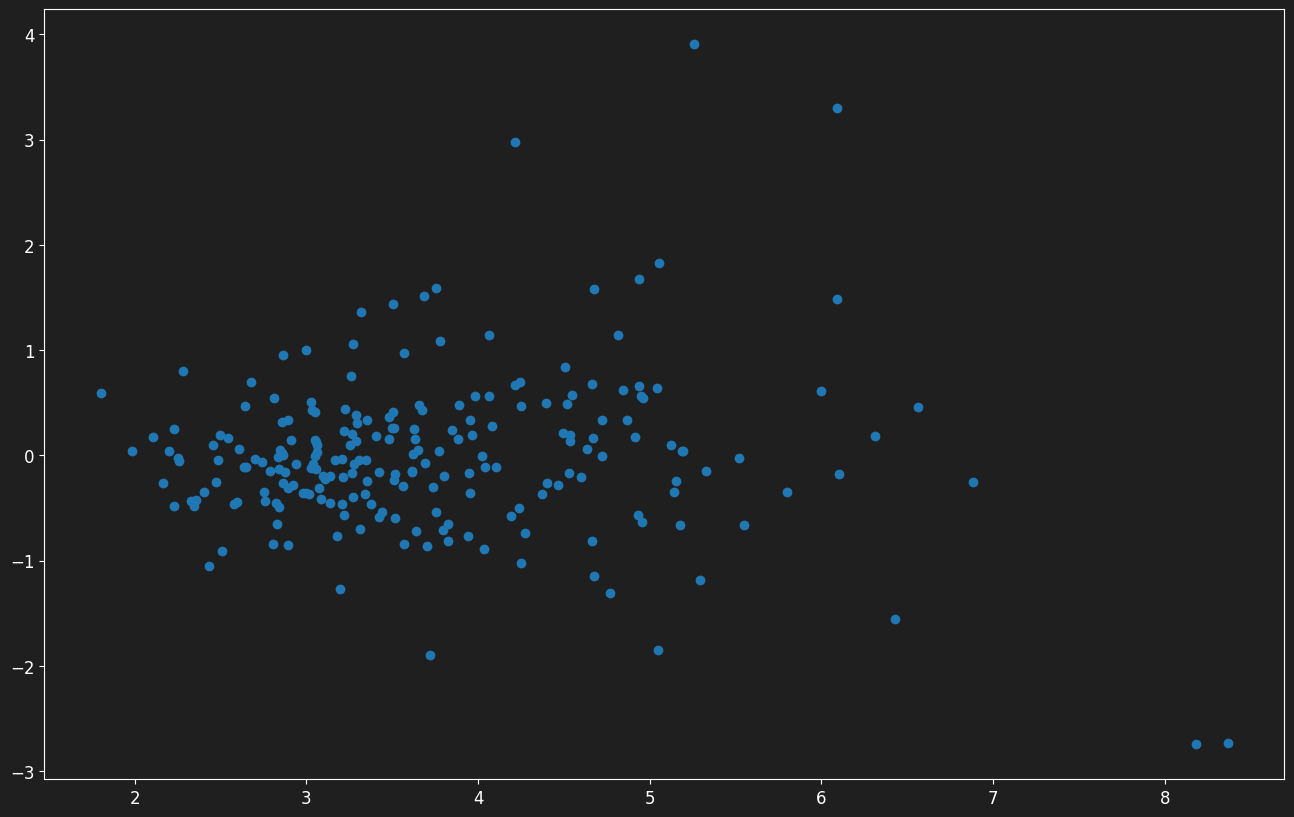

In [82]:
# By the looks of the graph above, the model is able to track the data quite well. I will now look at the residuals:
resids = arimaMod0.resid

fig, ax = plt.subplots()
ax.scatter(fitted, resids)
plt.show()

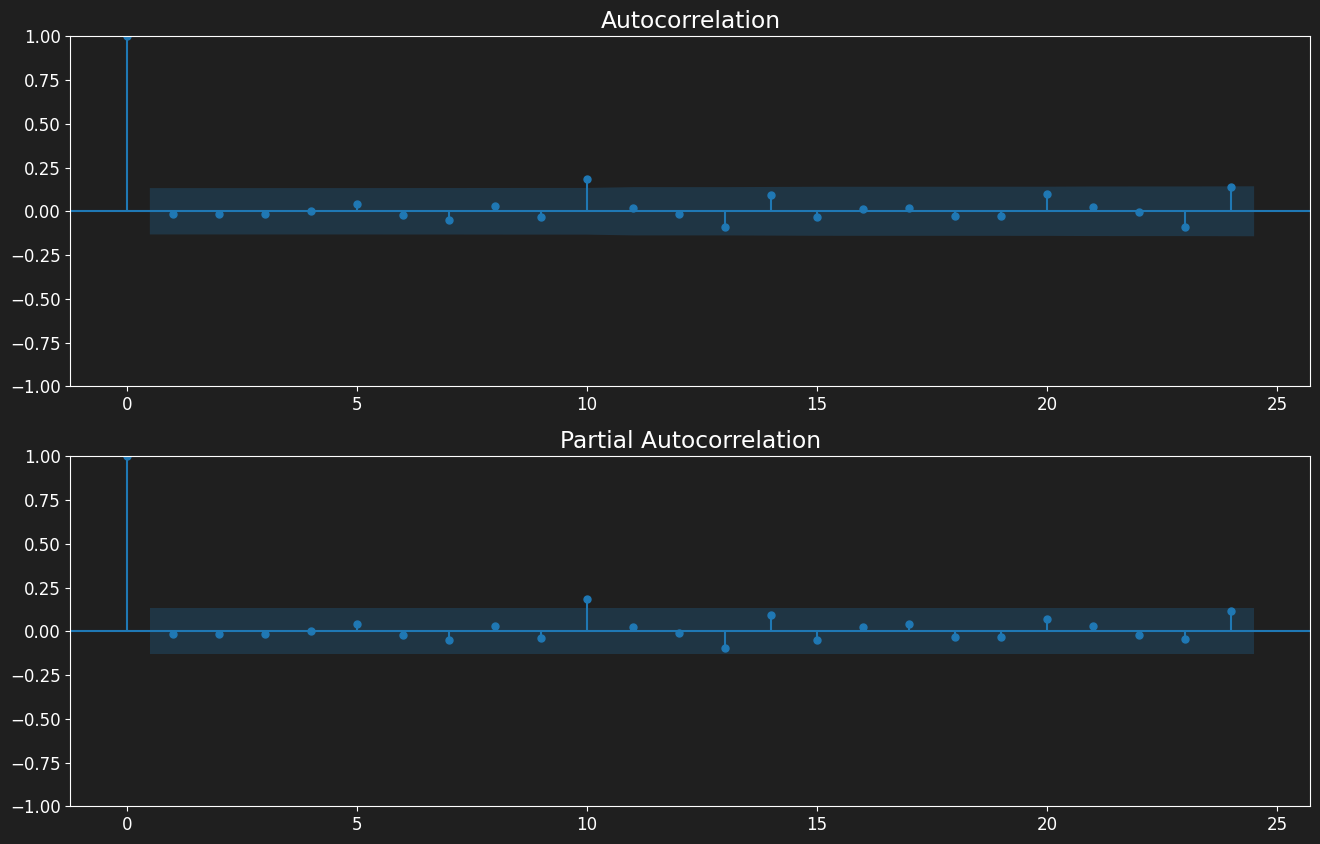

In [83]:
# Looking at the ACF and PACf of the residuals:
fig, ax = plt.subplots(2, 1)
plot_acf(resids, ax = ax[0])
plot_pacf(resids, ax = ax[1])
plt.show()

There is no obvious autocorrelation or other structure left in the residuals.

Creating a simple forecast based on the model:

In [87]:
forecast0 = arimaMod0.get_forecast(steps = 12).summary_frame()
forecast0 = forecast0.reset_index()
forecast0 = forecast0.rename(columns = {'index': 'date'})
forecast0

DK2,date,mean,mean_se,mean_ci_lower,mean_ci_upper
0,2019-01-01,4.696226,0.754094,3.218229,6.174223
1,2019-02-01,4.520209,0.974988,2.609267,6.431150
2,2019-03-01,4.375954,1.098698,2.222545,6.529363
3,2019-04-01,4.257730,1.174497,1.955759,6.559701
4,2019-05-01,4.160840,1.222772,1.764251,6.557430
5,2019-06-01,4.081434,1.254154,1.623337,6.539531
6,2019-07-01,4.016357,1.274799,1.517798,6.514917
7,2019-08-01,3.963023,1.288479,1.437651,6.488396
8,2019-09-01,3.919314,1.297586,1.376091,6.462537
9,2019-10-01,3.883492,1.303668,1.328350,6.438634


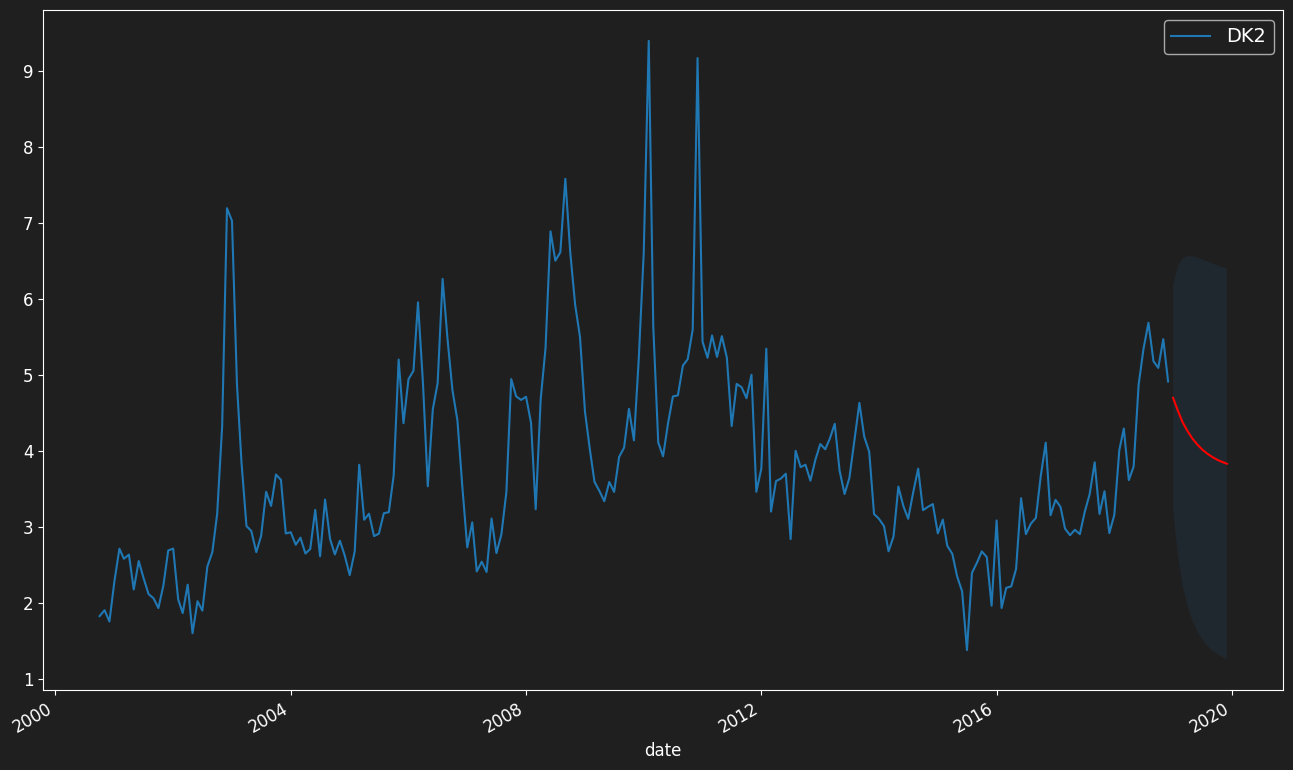

In [89]:
# Plotting the forecast, how the data might evolve in the future based on the model:
fig, ax = plt.subplots()
ax.plot(forecast0['date'], forecast0['mean'], color = 'red')
ax.fill_between(forecast0['date'], forecast0['mean_ci_lower'], forecast0['mean_ci_upper'], alpha = .1)
DK2_price.plot(ax = ax)
plt.show()

##### Adding an exogenous regressor to the model

In [90]:
# Adding an explanatory variable to the ARIMA model, extracting DK2 price and ets price from the dataframe, dependent on whether there exists ets data:
DK2_price = power_DF.loc[power_DF['ets_price'].notna(), ['date', 'DK2']].set_index('date')
ets_price = power_DF.loc[power_DF['ets_price'].notna(), ['date', 'ets_price']].set_index('date')
print(len(DK2_price), len(ets_price))

128 128


In [98]:
# order = (AR = 1, I = 1, MA = 0). The I = 1 means integrated of order 1, a first difference of both series is taken before running the regression.
arimaMod2 = ARIMA(DK2_price, ets_price, order = (1, 1, 0)).fit()
arimaMod2.summary()

C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    DK2   No. Observations:                  128
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -155.242
Date:                Sat, 09 Dec 2023   AIC                            316.484
Time:                        12:01:35   BIC                            325.017
Sample:                             0   HQIC                           319.951
                                - 128                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ets_price      0.1007      0.076      1.330      0.184      -0.048       0.249
ar.L1         -0.2034      0.039     -5.219      0.000      -0.280      -0.127
sigma2         0.6747      0.043     15.536      0.000       0.590       0.760
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):               218.26
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.18   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [124]:
# Creating the forecasts with two scenarios:
ets_price_high = np.linspace(25, 100, 12) # First scenario: We assume the ets price will rise to 100.
ets_price_low = np.repeat(25, 12) # Second scenario: We assume the ets price will stay constant at 25.

In [115]:
# Getting the forecasts:
forecast_highETS = arimaMod2.get_forecast(exog = ets_price_high, steps = 12).summary_frame()
forecast_lowETS = arimaMod2.get_forecast(exog = ets_price_low, steps = 12).summary_frame()

# Adding date columns because they are not included in the forecasts, since I had to remove some instances from the training data:
forecast_highETS['date'] = pd.date_range(start = '1/1/2019', freq = 'MS', periods = 12)
forecast_lowETS['date'] = pd.date_range(start = '1/1/2019', freq = 'MS', periods = 12)

C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
 

In [116]:
forecast_highETS

DK2,mean,mean_se,mean_ci_lower,mean_ci_upper,date
128,5.294801,0.821411,3.684865,6.904738,2019-01-01
129,5.943776,1.050190,3.885441,8.002112,2019-02-01
130,6.638115,1.255667,4.177052,9.099178,2019-03-01
131,7.323228,1.428649,4.523128,10.123328,2019-04-01
132,8.010217,1.583443,4.906727,11.113708,2019-05-01
133,8.696825,1.724283,5.317291,12.076358,2019-06-01
134,9.383510,1.854480,5.748796,13.018224,2019-07-01
135,10.070180,1.976113,6.197069,13.943290,2019-08-01
136,10.756852,2.090682,6.659190,14.854514,2019-09-01
137,11.443524,2.199291,7.132993,15.754056,2019-10-01


In [117]:
forecast_lowETS

DK2,mean,mean_se,mean_ci_lower,mean_ci_upper,date
128,5.294801,0.821411,3.684865,6.904738,2019-01-01
129,5.257104,1.050190,3.198769,7.315439,2019-02-01
130,5.264771,1.255667,2.803708,7.725834,2019-03-01
131,5.263211,1.428649,2.463112,8.063311,2019-04-01
132,5.263529,1.583443,2.160038,8.367019,2019-05-01
133,5.263464,1.724283,1.883931,8.642998,2019-06-01
134,5.263477,1.854480,1.628763,8.898191,2019-07-01
135,5.263475,1.976113,1.390364,9.136585,2019-08-01
136,5.263475,2.090682,1.165813,9.361137,2019-09-01
137,5.263475,2.199291,0.952944,9.574006,2019-10-01


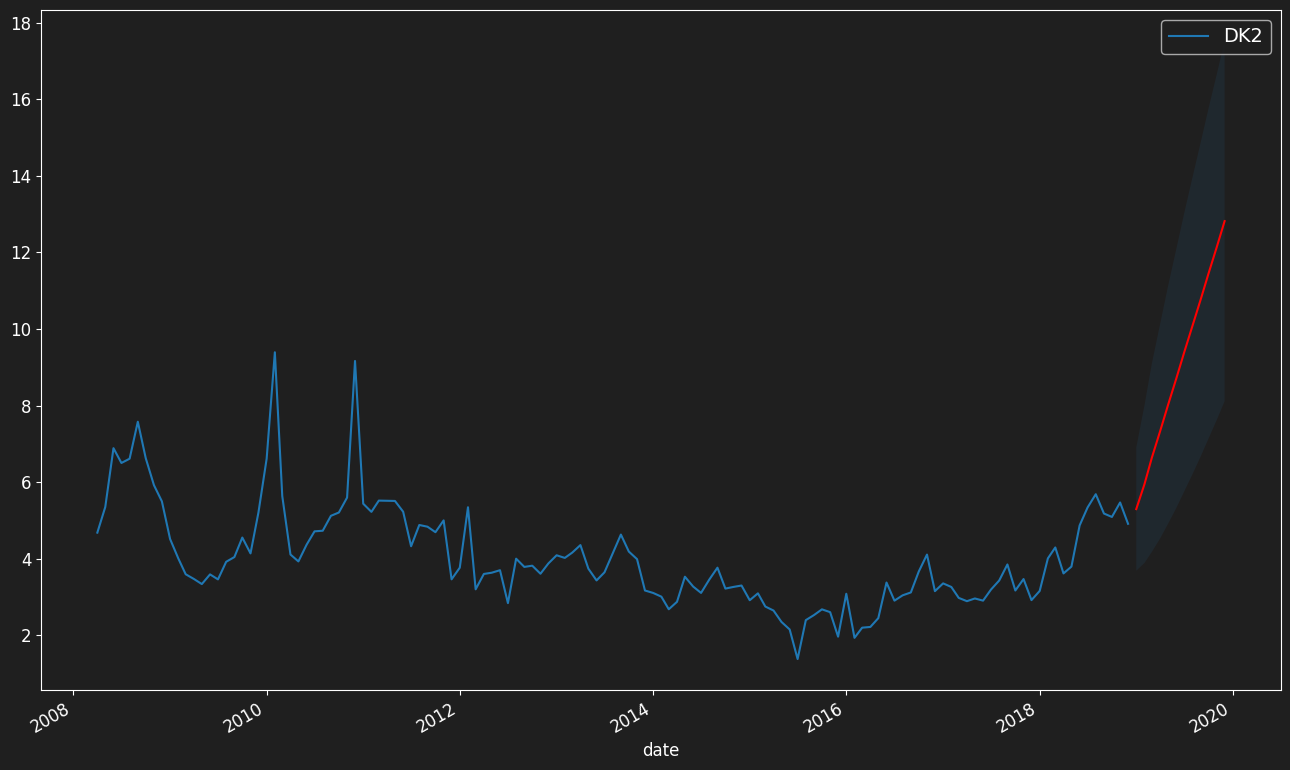

In [125]:
# Plotting the forecast for the first scenario:
fig, ax = plt.subplots()
ax.plot(forecast_highETS['date'], forecast_highETS['mean'], color = 'red')
ax.fill_between(forecast_highETS['date'], forecast_highETS['mean_ci_lower'], forecast_highETS['mean_ci_upper'], alpha = .1)
DK2_price.plot(ax = ax)
plt.show()

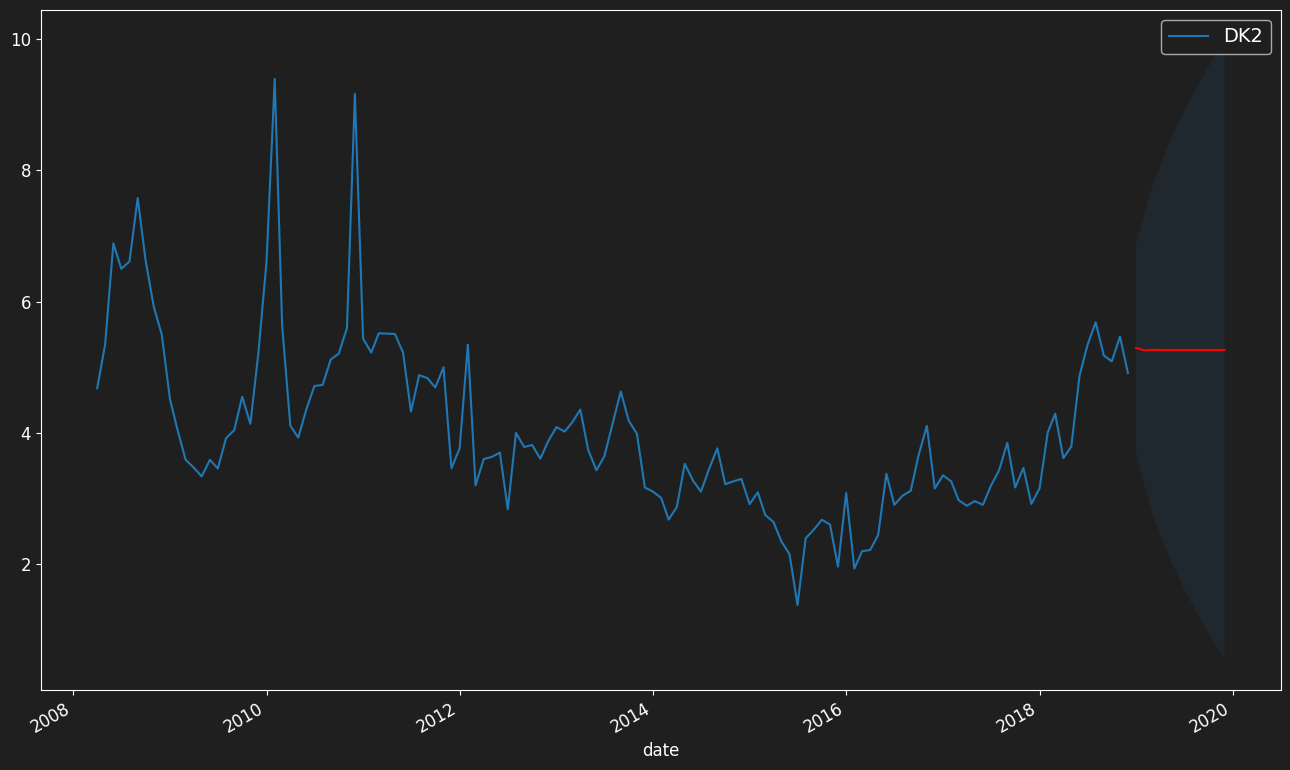

In [126]:
# Plotting the forecast for the second scenario:
fig, ax = plt.subplots()
ax.plot(forecast_lowETS['date'], forecast_lowETS['mean'], color = 'red')
ax.fill_between(forecast_lowETS['date'], forecast_lowETS['mean_ci_lower'], forecast_lowETS['mean_ci_upper'], alpha = .1)
DK2_price.plot(ax = ax)
plt.show()

##### Seasonality

A lot of time series (especially with high frequency) have seasonality. Meaning, they have recurring patterns at an hourly, daily, monthly, quarterly, or yearly level. Looking at some daily consumption data (electricity), which tends to show strong seasonality.

In [127]:
cons = pd.read_csv("http://jmaurit.github.io/analytics/labs/data/consumption-per-country_2019_daily.csv", sep=";")
cons

,date,NO,SE,FI,DK,Nordic,EE,LV,LT,Baltic
0,01/01/2019,410564,383617,252819,84659,1131658,20707,17307,29757,67771
1,02/01/2019,454919,466157,284691,98864,1304636,25007,21458,35864,82329
2,03/01/2019,457991,473677,308267,104761,1294453,27478,22842,37754,88074
3,04/01/2019,429673,439736,293880,102569,1219124,27995,23287,38536,89818
4,05/01/2019,401216,415149,279979,89429,1185774,25275,20908,34831,81014
...,...,...,...,...,...,...,...,...,...,...
360,27/12/2019,460167,437592,241661,93113,1232536,24133,19943,32877,76953
361,28/12/2019,442388,441166,251740,92159,1227453,23841,19371,32318,75530
362,29/12/2019,394046,396131,231863,91624,1113664,23689,18901,31866,74456
363,30/12/2019,394922,389466,229510,96420,1110331,23980,19782,33985,77747


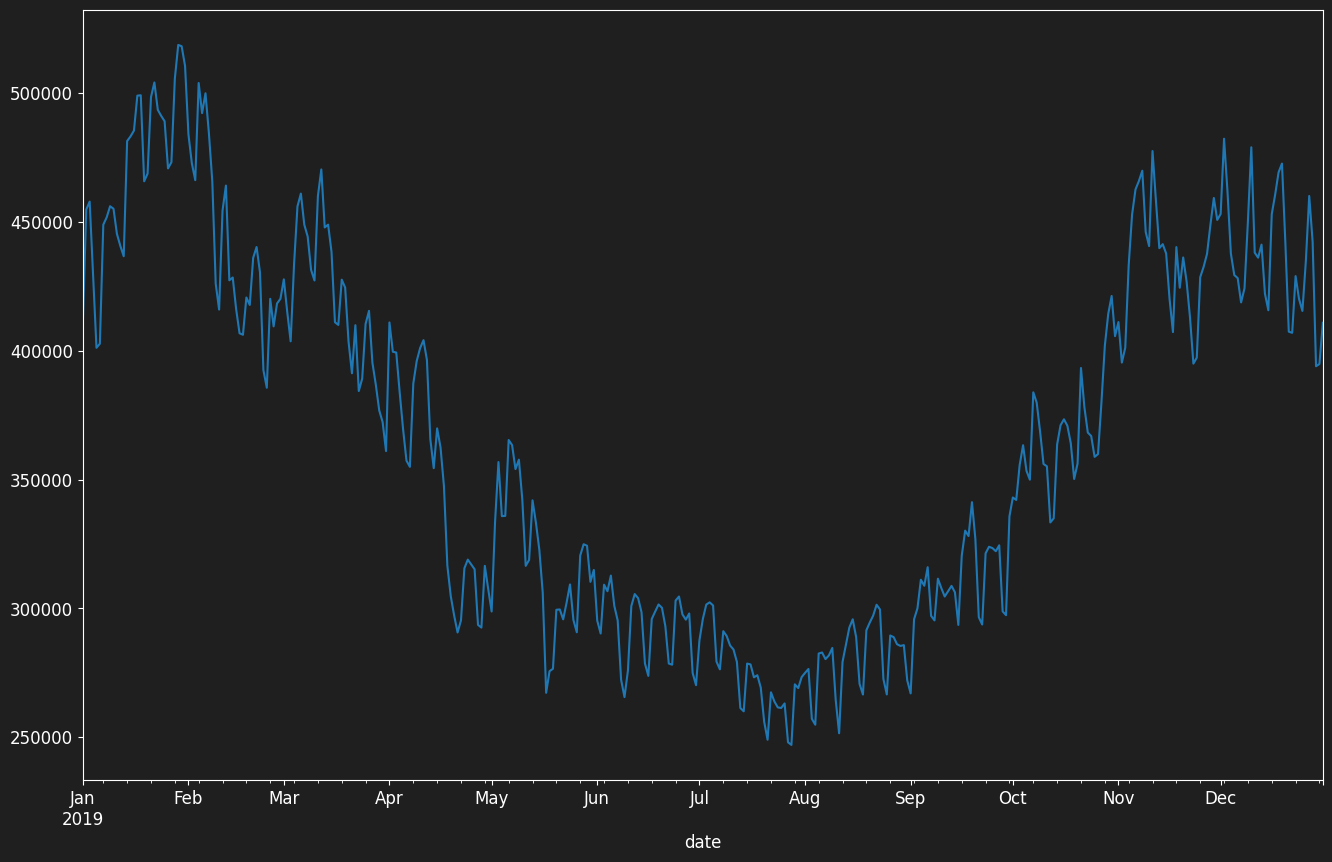

In [128]:
# Formatting the date column to be datetime:
cons['date'] = pd.to_datetime(cons['date'], format = '%d/%m/%Y')

# Isolating the norwegian consumption:
NO_cons = cons.set_index('date').loc[:, 'NO']

# Plotting the evolution:
NO_cons.plot()
plt.show()

Here we see the weekly variation (you can count 52 ups and downs). You can also get a hint at the yearly evolution, though since this is only covering one year, we cannot see a repeating pattern, only speculate that the consumption decreases during the warmer months (which can be expected). 

We want to deal with the weekly seasonality in the modeling, we have a few choices. The first: try to remove the seasonal component, and just forecast the seasonally adjusted data. One tool for doing this is STL decomposition (Seasonal and Trend decomposition using Loess).

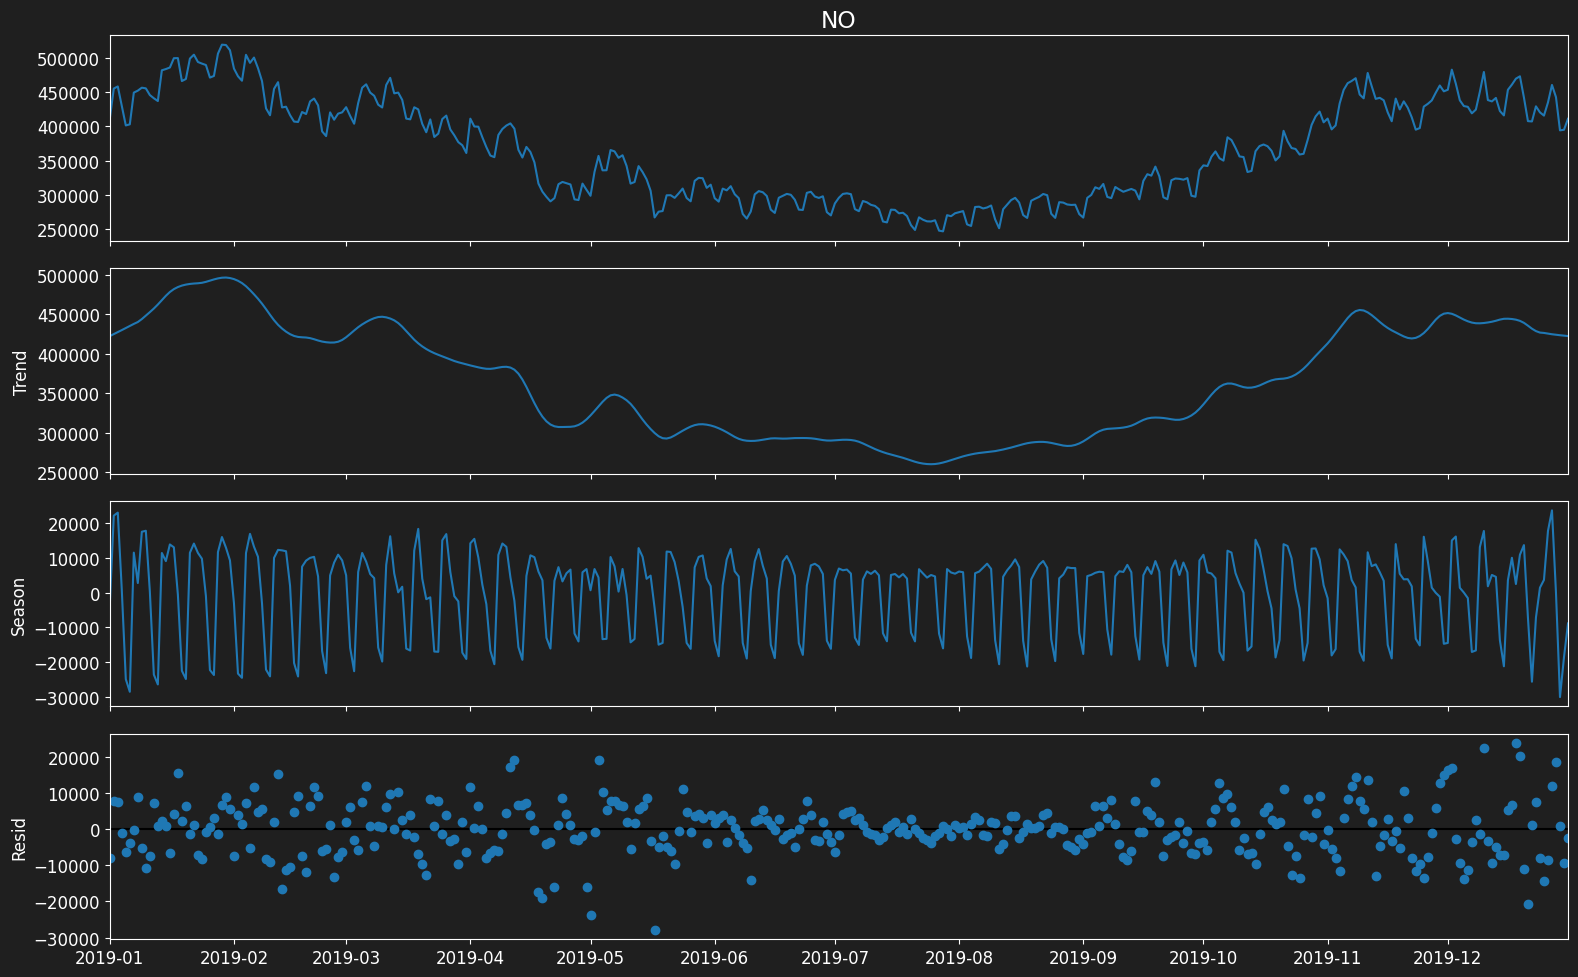

In [134]:
from statsmodels.tsa.seasonal import STL

stl = STL(NO_cons, seasonal = 7)
res = stl.fit()
fig = res.plot()

In [135]:
# Creating a seasonally adjusted series, the seasonal component is removed and we are left with a series composed of the trend and non-seasonal errors.
NO_cons_sa = res.trend + res.resid

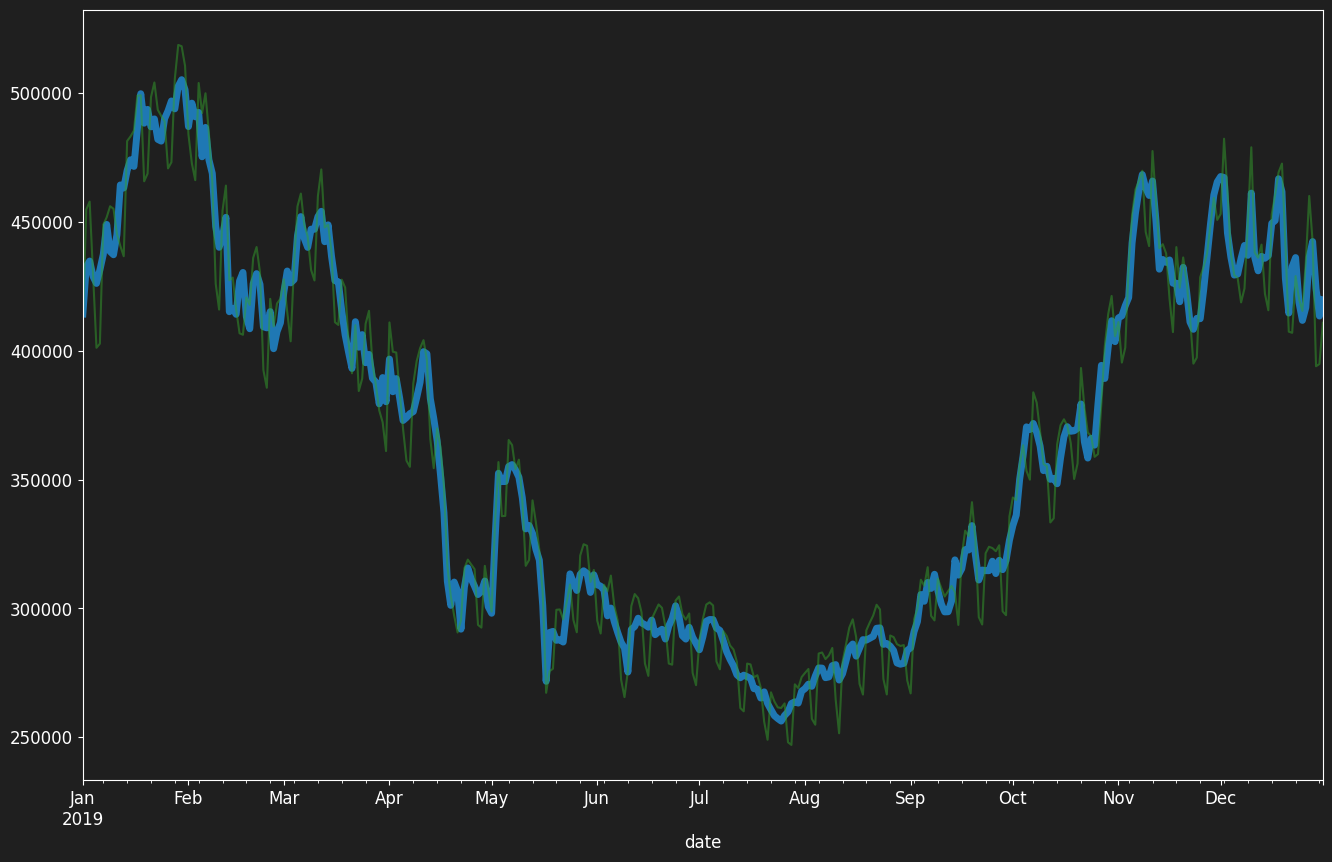

In [136]:
fig, ax = plt.subplots()
NO_cons_sa.plot(ax = ax, lw = 5)
NO_cons.plot(ax = ax, alpha = .5)
plt.show()

From this data we could create a forecast model, but we might be interested in including the seasonality in the forecast as well as the trend. 

We recognize that the series looks quite non-stationary. Since we have very pronounced seasonality, instead of taking a normal first-difference, we can take a seasonal difference. 

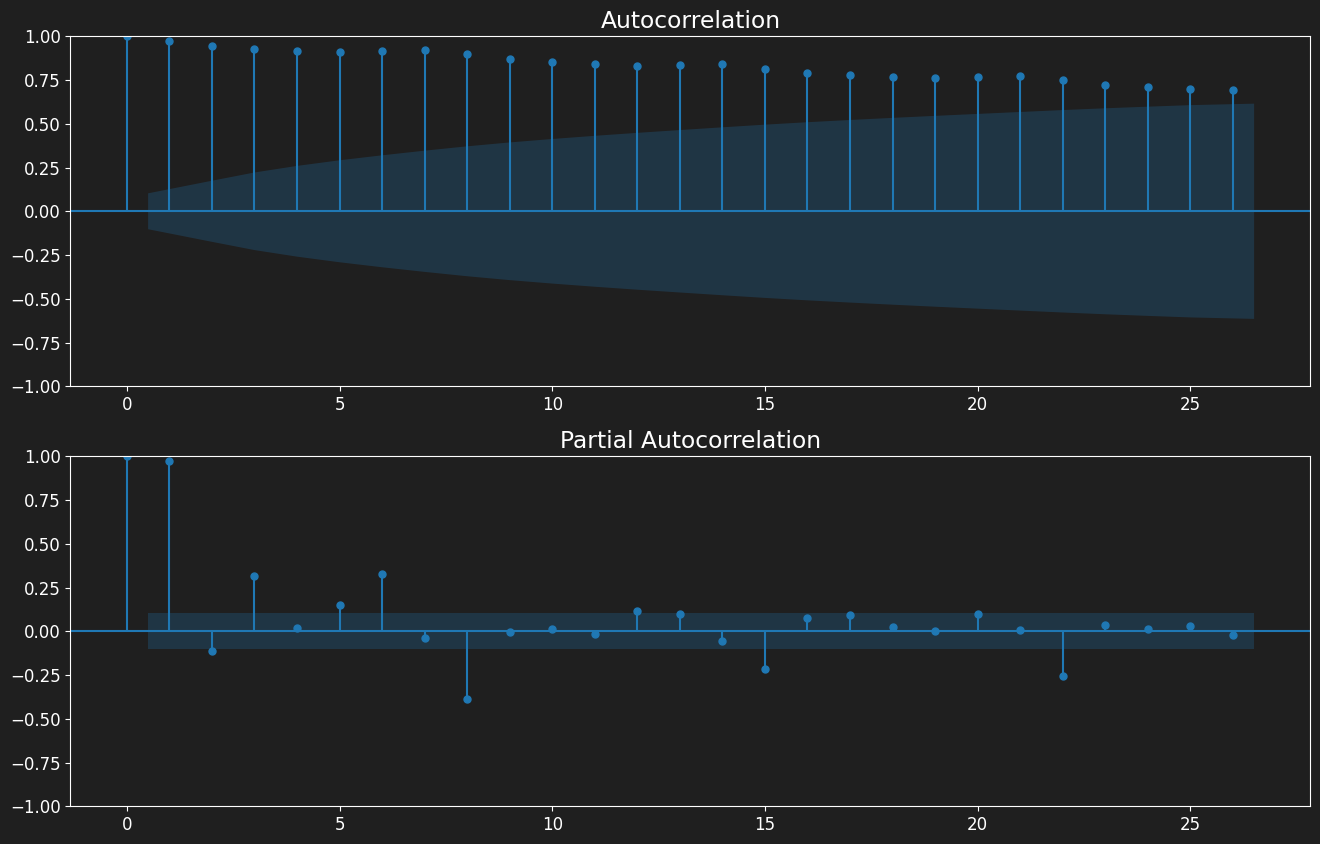

In [137]:
# Looking at the differenced series and the ACF and PACF functions:
fig, ax = plt.subplots(2, 1)
plot_acf(NO_cons, ax = ax[0])
plot_pacf(NO_cons, ax = ax[1])
plt.show()

In [138]:
arimaMod3 = ARIMA(NO_cons, order = (2, 0, 1), seasonal_order = (2, 1, 1, 7)).fit()
arimaMod3.summary()

C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                    
=======================================================================================
Dep. Variable:                              NO   No. Observations:                  365
Model:             ARIMA(2, 0, 1)x(2, 1, 1, 7)   Log Likelihood               -4002.952
Date:                         Sat, 09 Dec 2023   AIC                           8019.905
Time:                                 13:27:16   BIC                           8047.068
Sample:                             01-01-2019   HQIC                          8030.708
                                  - 12-31-2019                                         
Covariance Type:                           opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4096      0.027     51.601      0.000       1.356       1.463
ar.L2         -0.4171      0.026    -16.314      0.000      -0.467      -0.367
ma.L1         -0.8774      0.015    -60.284      0.000      -0.906      -0.849
ar.S.L7        0.3236      0.030     10.675      0.000       0.264       0.383
ar.S.L14       0.1033      0.015      6.740      0.000       0.073       0.133
ma.S.L7       -0.9487      0.023    -41.099      0.000      -0.994      -0.903
sigma2      1.994e+08    3.4e-11   5.87e+18      0.000    1.99e+08    1.99e+08
===================================================================================
Ljung-Box (L1) (Q):                  53.69   Jarque-Bera (JB):               482.83
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.45   Skew:                            -0.75
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number  2e+34. Standard errors may be unstable.
"""

In [139]:
# Generating a forecast based on the seasonal ARIMA model:
forecast_cons = arimaMod3.get_forecast(steps = 30).summary_frame()
forecast_cons = forecast_cons.reset_index()
forecast_cons = forecast_cons.rename(columns = {'index': 'date'})

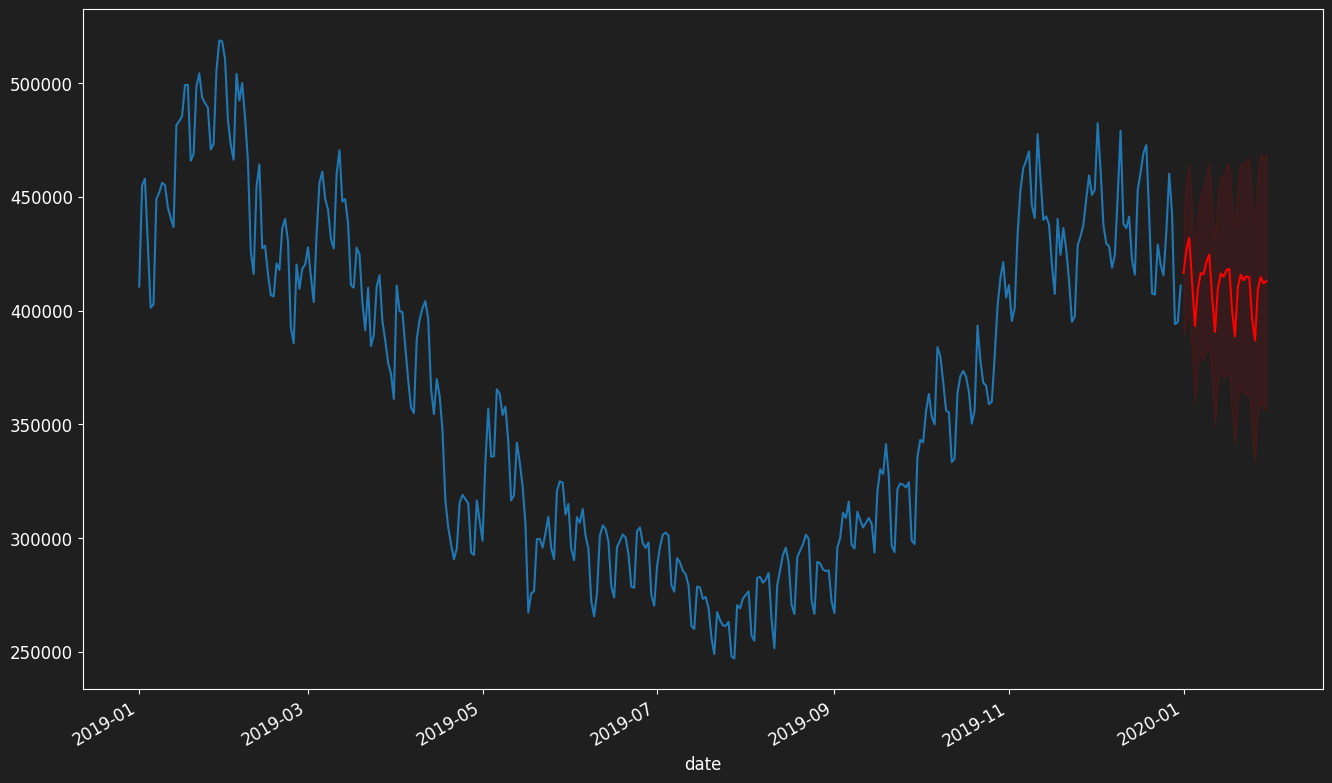

In [141]:
# Plotting the forecast with seasonality included:
fig, ax = plt.subplots()
ax.plot(forecast_cons['date'], forecast_cons['mean'], color = 'red')
ax.fill_between(forecast_cons['date'], forecast_cons['mean_ci_lower'], forecast_cons['mean_ci_upper'], alpha = .1, color = 'red')
NO_cons.plot(ax = ax)
plt.show()